### This code trace teh bathymteric map transversal transect T2 from the hydropower station to the cliff using a new device: Deeper PRO+2 A2AD
we used this new device to measure the transversal transect of the lake T2. It measures the depth with a GPS and time based on the number of milisecondes from the 1st january 1970 to now. 
This code is composed in 2 part, the first one is based directly on the data from the Deeper. the other one use the data smoothed as a function of the coordinates to avoid limit the impact of the lateral drift of the boat. 

The sondar was used 15 times in the transect at: (heure moyenne entre le début et la fin de la prise généralement 3-4min)
- T2_P1 = 11h30
- T2_P2 = 11h35
- T2_P3 = 11h40
- T2_P4 = 11h46
- T2_P5 = 11h50
- T2_P6 = 11h56
- T2_P7 = 12h03
- T2_P8 = 12h07
- T2_P9 = 12h14
- T2_P10 = 12h16
- T2_P11 = 12h18
- T2_P12 = 12h22
- T2_P13 = 12h24
- T2_P14 = 12h26
- T2_P15 = 12h28



## Part 1: Unadjusted data

Lignes après coupure : 43568
Dernière mesure : 2026-06-04 12:29:59.986000+02:00

=== Points T2 (valeurs extraites) ===
                                datetime   latitude longitude   depth  \
point                                                                   
T2_P1   2026-06-04 11:29:59.976000+02:00  46.344536  6.842029   6.848   
T2_P2   2026-06-04 11:35:00.039000+02:00  46.344607  6.842057  19.753   
T2_P3   2026-06-04 11:40:00.001000+02:00  46.344707  6.841978  24.446   
T2_P4   2026-06-04 11:45:59.993000+02:00  46.344831  6.841974   32.72   
T2_P5   2026-06-04 11:49:59.999000+02:00  46.345001  6.841853  32.397   
T2_P6   2026-06-04 11:56:00.034000+02:00  46.345472   6.84214  33.188   
T2_P7   2026-06-04 12:02:59.958000+02:00  46.346058  6.842548  31.169   
T2_P8   2026-06-04 12:06:59.998000+02:00  46.346309  6.842596  27.849   
T2_P9   2026-06-04 12:14:00.033000+02:00  46.346549  6.842421    13.3   
T2_P10  2026-06-04 12:15:59.964000+02:00  46.346581  6.842125  11.458   
T2_P1

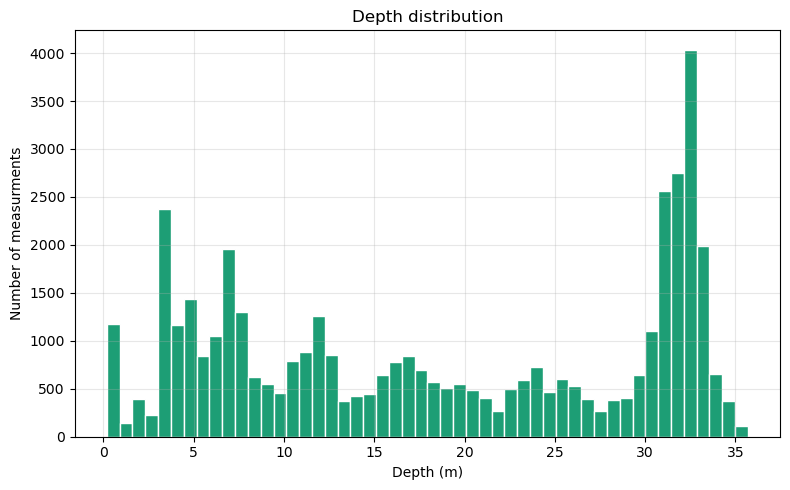

<Figure size 640x480 with 0 Axes>

✓ profil_profondeur.png sauvegardé


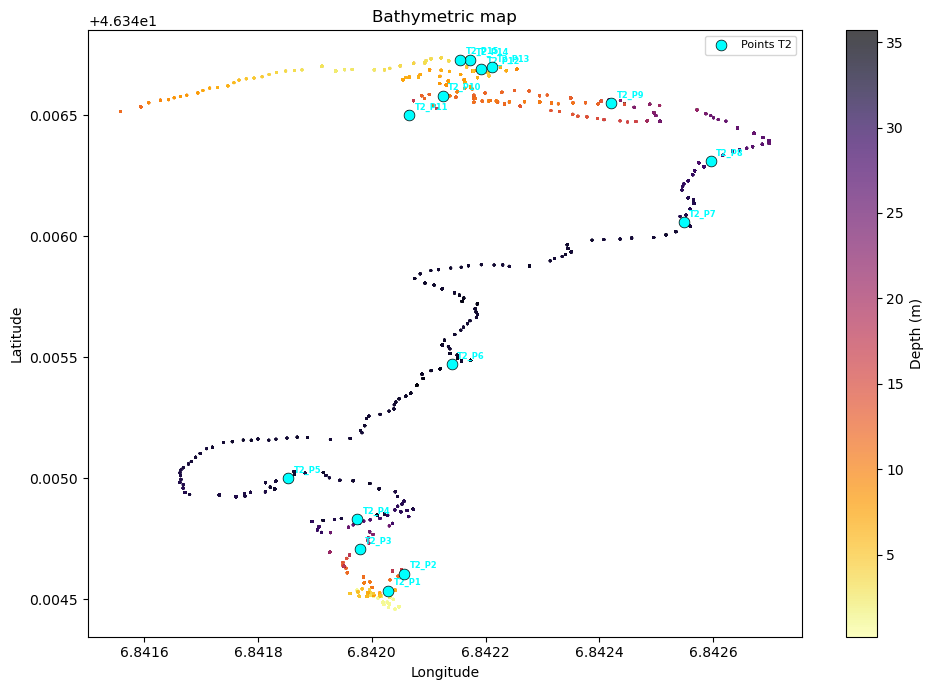

✓ carte_bathymetrique.png sauvegardé


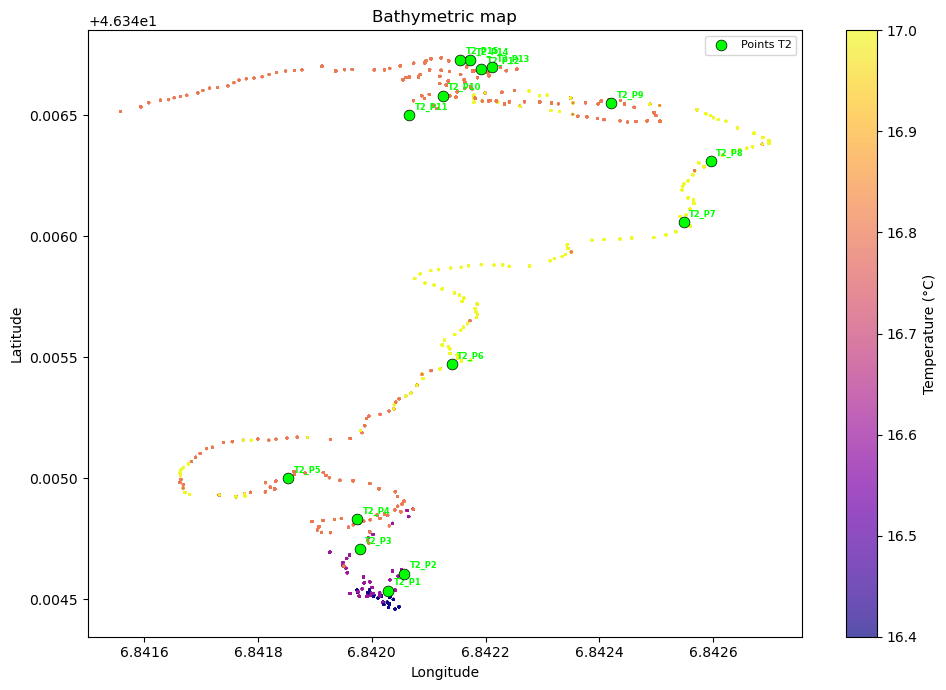

✓ carte_thermique.png sauvegardé


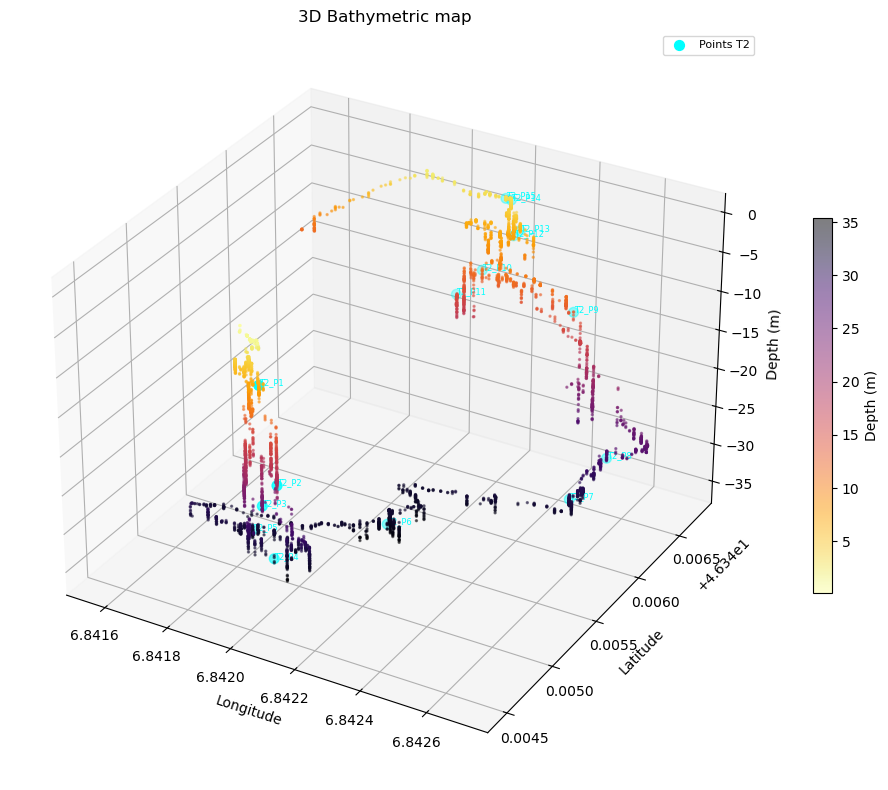

✓ visualisation_3d.png sauvegardé


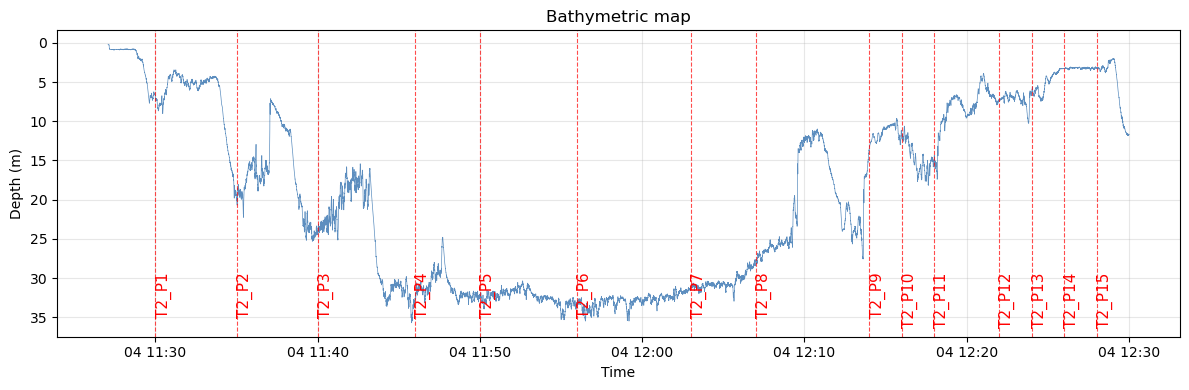

✓ serie_temporelle.png sauvegardé

Corrélation depth–température : r = 0.5658


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ── 1. Chargement ─────────────────────────────────────────────────────────────
chemin = r"../data/bathymetry/20260603/Level 0/sonar_deeper_bathymetric_level0_2026.csv"

df = pd.read_csv(chemin, sep=",")
df.columns = ["latitude", "longitude", "depth", "temperature", "time_ms"]

df["latitude"]    = df["latitude"].ffill().bfill()
df["longitude"]   = df["longitude"].ffill().bfill()
df["temperature"] = df["temperature"].ffill().bfill()

df["datetime"] = (pd.to_datetime(df["time_ms"], unit="ms")
                  .dt.tz_localize("UTC")
                  .dt.tz_convert("Europe/Zurich"))

# ── 2. Coupure à 12h30 ────────────────────────────────────────────────────────
df = df[df["datetime"] < pd.Timestamp("2026-06-04 12:30:00", tz="Europe/Zurich")]
print(f"Lignes après coupure : {len(df)}")
print(f"Dernière mesure : {df['datetime'].max()}")

# ── 3. Points de mesure T2 ────────────────────────────────────────────────────
points_t2 = {
    "T2_P1":  "2026-06-04 11:30:00",
    "T2_P2":  "2026-06-04 11:35:00",
    "T2_P3":  "2026-06-04 11:40:00",
    "T2_P4":  "2026-06-04 11:46:00",
    "T2_P5":  "2026-06-04 11:50:00",
    "T2_P6":  "2026-06-04 11:56:00",
    "T2_P7":  "2026-06-04 12:03:00",
    "T2_P8":  "2026-06-04 12:07:00",
    "T2_P9":  "2026-06-04 12:14:00",
    "T2_P10": "2026-06-04 12:16:00",
    "T2_P11": "2026-06-04 12:18:00",
    "T2_P12": "2026-06-04 12:22:00",
    "T2_P13": "2026-06-04 12:24:00",
    "T2_P14": "2026-06-04 12:26:00",
    "T2_P15": "2026-06-04 12:28:00",
}

# Pour chaque point, trouver la ligne du df la plus proche en temps
tz = "Europe/Zurich"
rows_t2 = {}
for name, t in points_t2.items():
    ts = pd.Timestamp(t, tz=tz)
    idx = (df["datetime"] - ts).abs().idxmin()
    rows_t2[name] = df.loc[idx]

df_t2 = pd.DataFrame(rows_t2).T
df_t2.index.name = "point"
print("\n=== Points T2 (valeurs extraites) ===")
print(df_t2[["datetime", "latitude", "longitude", "depth", "temperature"]])

# ── 4. Profil thermique vertical ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(df["depth"], bins=50, color="#1D9E75", edgecolor="white")
ax.set_xlabel("Depth (m)")
ax.set_ylabel("Number of measurments")
ax.set_title("Depth distribution")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("Figures/distribution_profondeurs.png", dpi=150)
plt.show()

plt.tight_layout()
plt.savefig("Figures/profil_profondeur.png", dpi=150)
plt.show()
print("✓ profil_profondeur.png sauvegardé")

# ── 5. Carte bathymétrique (profondeur) ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(df["longitude"], df["latitude"],
                c=df["depth"], cmap="inferno_r",
                s=1, alpha=0.7)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Depth (m)")

# Points T2
ax.scatter(df_t2["longitude"], df_t2["latitude"],
           color="cyan", s=60, zorder=5, label="Points T2", edgecolors="black", linewidths=0.5)
for name, row in df_t2.iterrows():
    ax.annotate(name, (row["longitude"], row["latitude"]),
                fontsize=6, color="cyan",
                xytext=(4, 4), textcoords="offset points",
                fontweight="bold")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Bathymetric map")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("Figures/carte_bathymetrique.png", dpi=150)
plt.show()
print("✓ carte_bathymetrique.png sauvegardé")

# ── 6. Carte thermique (température) ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(df["longitude"], df["latitude"],
                c=df["temperature"], cmap="plasma",
                s=1, alpha=0.7)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Temperature (°C)")

ax.scatter(df_t2["longitude"], df_t2["latitude"],
           color="lime", s=60, zorder=5, label="Points T2", edgecolors="black", linewidths=0.5)
for name, row in df_t2.iterrows():
    ax.annotate(name, (row["longitude"], row["latitude"]),
                fontsize=6, color="lime",
                xytext=(4, 4), textcoords="offset points",
                fontweight="bold")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Bathymetric map")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("Figures/carte_thermique.png", dpi=150)
plt.show()
print("✓ carte_thermique.png sauvegardé")

# ── 7. Visualisation 3D ───────────────────────────────────────────────────────
df_sample = df.sample(n=min(5000, len(df)), random_state=42)

fig = plt.figure(figsize=(11, 8))
ax3d = fig.add_subplot(111, projection="3d")
sc3d = ax3d.scatter(
    df_sample["longitude"], df_sample["latitude"], -df_sample["depth"],
    c=df_sample["depth"], cmap="inferno_r", s=2, alpha=0.5
)
# Points T2 en 3D
ax3d.scatter(df_t2["longitude"], df_t2["latitude"], -df_t2["depth"],
             color="cyan", s=50, zorder=5, label="Points T2")
for name, row in df_t2.iterrows():
    ax3d.text(row["longitude"], row["latitude"], -row["depth"],
              name, fontsize=6, color="cyan")

plt.colorbar(sc3d, ax=ax3d, label="Depth (m)", shrink=0.5)
ax3d.set_xlabel("Longitude")
ax3d.set_ylabel("Latitude")
ax3d.set_zlabel("Depth (m)")
ax3d.set_title("3D Bathymetric map")
ax3d.legend(fontsize=8)
plt.tight_layout()
plt.savefig("Figures/visualisation_3d.png", dpi=150)
plt.show()
print("✓ visualisation_3d.png sauvegardé")

# ── 8. Série temporelle ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["datetime"], df["depth"], linewidth=0.5, color="#185FA5", alpha=0.7)

for name, row in df_t2.iterrows():
    ax.axvline(row["datetime"], color="red", linewidth=0.8, alpha=0.7, linestyle="--")
    ax.text(row["datetime"], df["depth"].max() * 0.82, name,
            fontsize=11, color="red", rotation=90, va="top")

ax.invert_yaxis()
ax.set_xlabel("Time")
ax.set_ylabel("Depth (m)")
ax.set_title("Bathymetric map")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Figures/serie_temporelle.png", dpi=150)
plt.show()
print("✓ serie_temporelle.png sauvegardé")

# ── 9. Corrélation ────────────────────────────────────────────────────────────
corr = df["depth"].corr(df["temperature"])
print(f"\nCorrélation depth–température : r = {corr:.4f}")

In [4]:
# 10. Résumé statistique

print(f"Total measurements    : {len(df)}")
print(f"Time start            : {df['datetime'].min()}")
print(f"Time end              : {df['datetime'].max()}")
print(f"\nDepth (m)")
print(f"  Min                 : {df['depth'].min():.2f} m")
print(f"  Max                 : {df['depth'].max():.2f} m")
print(f"  Mean                : {df['depth'].mean():.2f} m")
print(f"  Std                 : {df['depth'].std():.2f} m")
print(f"\nTemperature (°C)")
print(f"  Min                 : {df['temperature'].min():.2f} °C")
print(f"  Max                 : {df['temperature'].max():.2f} °C")
print(f"  Mean                : {df['temperature'].mean():.2f} °C")
print(f"  Std                 : {df['temperature'].std():.2f} °C")
print(f"\nCorrelation depth–temperature : r = {corr:.4f}")
print(f"\n=== T2 points summary ===")
print(df_t2[["datetime", "depth", "temperature"]].to_string())

Total measurements    : 43568
Time start            : 2026-06-04 11:27:05.052000+02:00
Time end              : 2026-06-04 12:29:59.986000+02:00

Depth (m)
  Min                 : 0.19 m
  Max                 : 35.70 m
  Mean                : 18.74 m
  Std                 : 11.34 m

Temperature (°C)
  Min                 : 16.40 °C
  Max                 : 17.00 °C
  Mean                : 16.79 °C
  Std                 : 0.16 °C

Correlation depth–temperature : r = 0.5658

=== T2 points summary ===
                                datetime   depth temperature
point                                                       
T2_P1   2026-06-04 11:29:59.976000+02:00   6.848        16.6
T2_P2   2026-06-04 11:35:00.039000+02:00  19.753        16.6
T2_P3   2026-06-04 11:40:00.001000+02:00  24.446        16.6
T2_P4   2026-06-04 11:45:59.993000+02:00   32.72        16.8
T2_P5   2026-06-04 11:49:59.999000+02:00  32.397        16.8
T2_P6   2026-06-04 11:56:00.034000+02:00  33.188        17.0
T2_P7   20

## Part 2: Smoothed data

Longueur totale du transect rectiligne : 222.2 m
Écart latéral max du bateau : 84.7 m
Points bruts   : 43568
Points lissés  : 178 (résolution ~1 m)


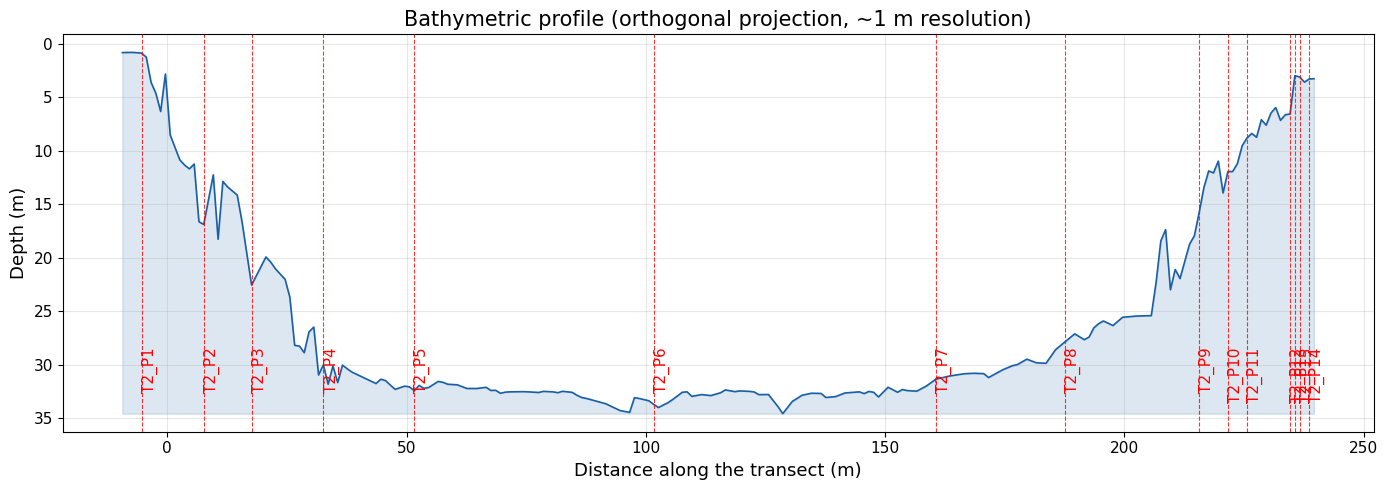

✓ transect_profil.png sauvegardé


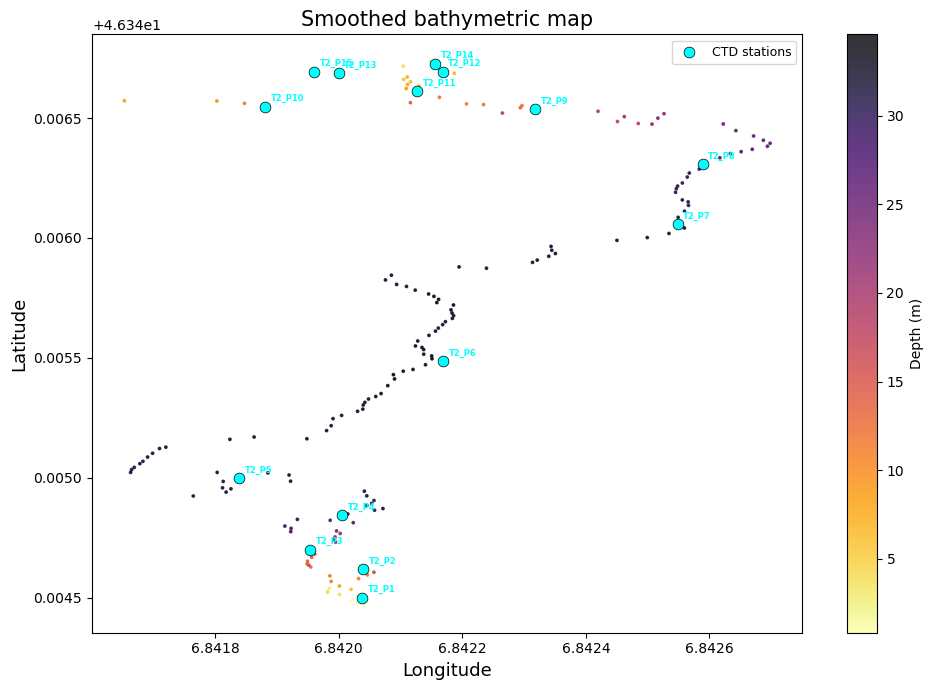

✓ carte_bathymetrique_smooth.png sauvegardé


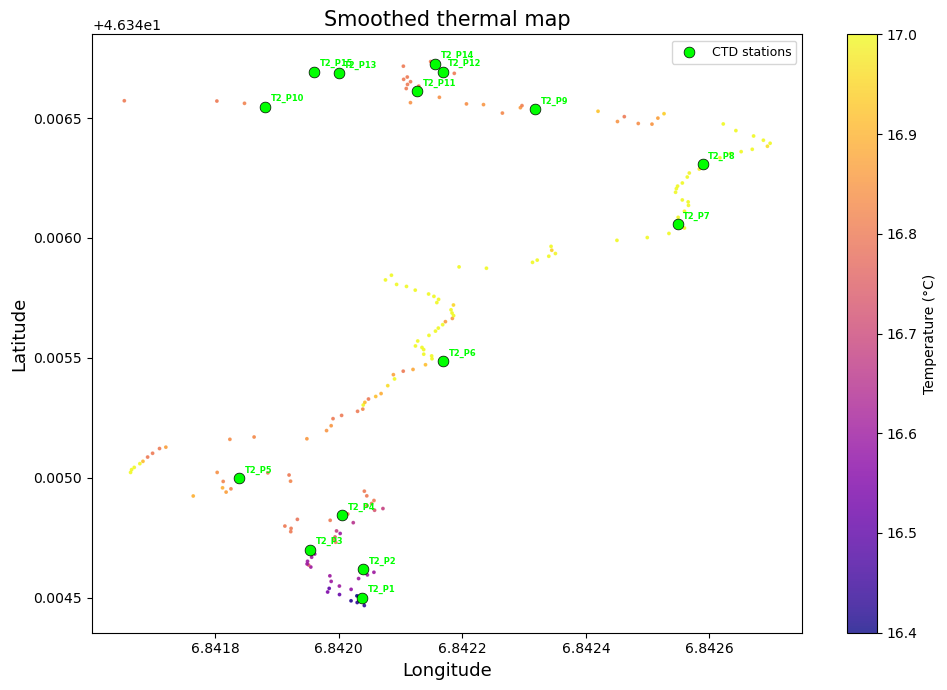

✓ carte_thermique_smooth.png sauvegardé


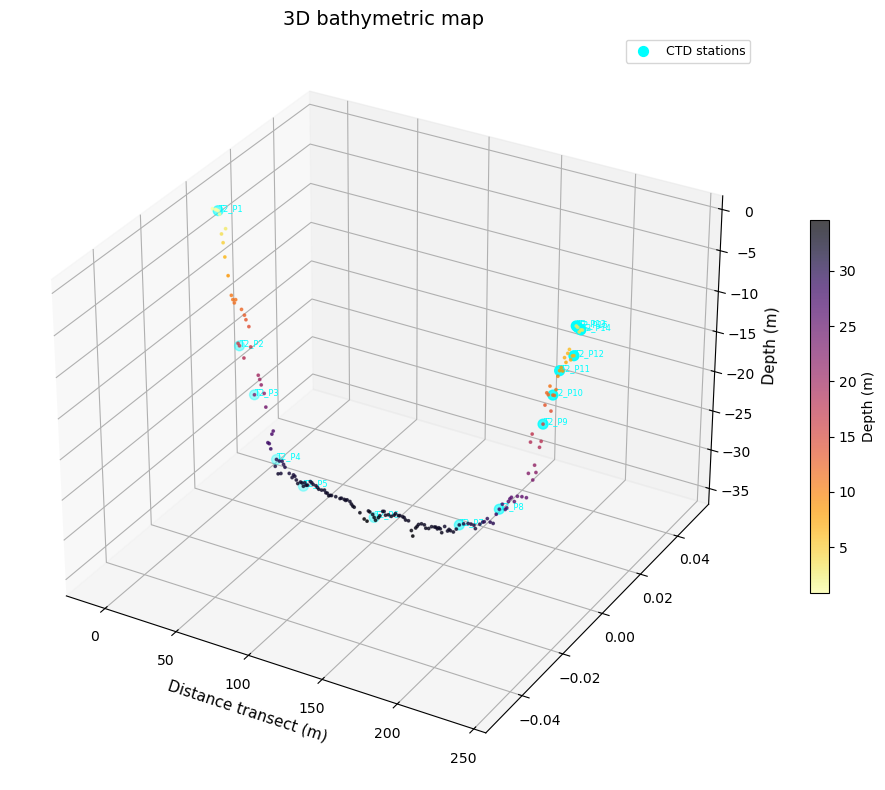

✓ visualisation_3d_smooth.png sauvegardé


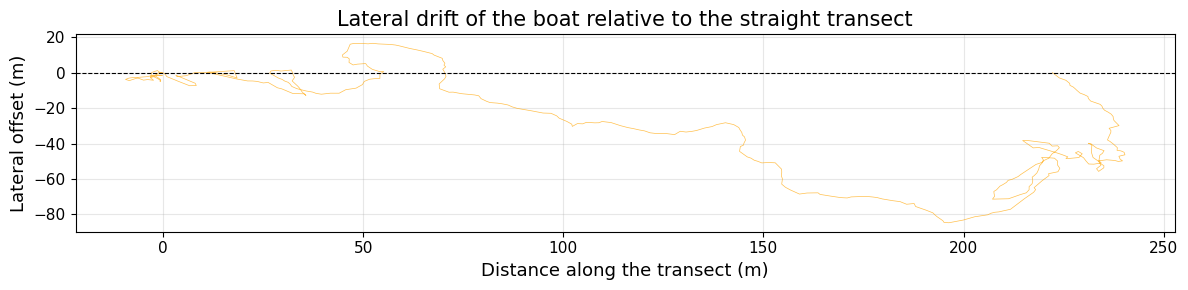

✓ ecart_lateral.png sauvegardé

=== Résumé ===
Distance transect  : 222 m
Dérive max         : 84.7 m
Points bruts       : 43568
Points lissés      : 178
Profondeur max     : 34.59 m
Température moy.   : 16.85 °C


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ── 1. Chargement ─────────────────────────────────────────────────────────────
chemin = r"../data/bathymetry/20260603/Level 0/sonar_deeper_bathymetric_level0_2026.csv"

df = pd.read_csv(chemin, sep=",")
df.columns = ["latitude", "longitude", "depth", "temperature", "time_ms"]

df["latitude"]    = df["latitude"].ffill().bfill()
df["longitude"]   = df["longitude"].ffill().bfill()
df["temperature"] = df["temperature"].ffill().bfill()

df["datetime"] = (pd.to_datetime(df["time_ms"], unit="ms")
                  .dt.tz_localize("UTC")
                  .dt.tz_convert("Europe/Zurich"))

df = df[df["datetime"] < pd.Timestamp("2026-06-04 12:30:00", tz="Europe/Zurich")].copy()
df = df.reset_index(drop=True)

# ── 2. Conversion lat/lon → mètres (repère local) ────────────────────────────
R = 6371000
lat0 = df["latitude"].iloc[0]
lon0 = df["longitude"].iloc[0]

df["x_m"] = np.radians(df["longitude"] - lon0) * np.cos(np.radians(lat0)) * R
df["y_m"] = np.radians(df["latitude"]  - lat0) * R

# ── 3. Projection orthogonale sur l'axe du transect ──────────────────────────
lat_start, lon_start = 46.34453798644245, 6.841974053531885
lat_end,   lon_end   = 46.346515654586256, 6.841558394953608

x_start = np.radians(lon_start - lon0) * np.cos(np.radians(lat0)) * R
y_start = np.radians(lat_start - lat0) * R
x_end   = np.radians(lon_end   - lon0) * np.cos(np.radians(lat0)) * R
y_end   = np.radians(lat_end   - lat0) * R

tx = x_end - x_start
ty = y_end - y_start
t_len = np.sqrt(tx**2 + ty**2)
tx_n, ty_n = tx / t_len, ty / t_len

print(f"Longueur totale du transect rectiligne : {t_len:.1f} m")

dx = df["x_m"] - x_start
dy = df["y_m"] - y_start
df["dist_transect"] = dx * tx_n + dy * ty_n
df["dist_lateral"]  = -dx * ty_n + dy * tx_n

print(f"Écart latéral max du bateau : {df['dist_lateral'].abs().max():.1f} m")

# ── 4. Binning à 1 m ──────────────────────────────────────────────────────────
bin_size = 1.0
bins = np.arange(df["dist_transect"].min(), df["dist_transect"].max() + bin_size, bin_size)
df["bin"] = pd.cut(df["dist_transect"], bins=bins, labels=bins[:-1]).astype(float)

df_smooth = (df.groupby("bin", as_index=False)
               .agg(
                   latitude    = ("latitude",    "mean"),
                   longitude   = ("longitude",   "mean"),
                   depth       = ("depth",        "mean"),
                   temperature = ("temperature",  "mean"),
                   datetime    = ("datetime",     "first"),
               ))
df_smooth = df_smooth.dropna().reset_index(drop=True)
df_smooth["dist_transect"] = df_smooth["bin"]

print(f"Points bruts   : {len(df)}")
print(f"Points lissés  : {len(df_smooth)} (résolution ~1 m)")

# ── 5. Points T2 ──────────────────────────────────────────────────────────────
points_t2 = {
    "T2_P1":  "2026-06-04 11:30:00",
    "T2_P2":  "2026-06-04 11:35:00",
    "T2_P3":  "2026-06-04 11:40:00",
    "T2_P4":  "2026-06-04 11:46:00",
    "T2_P5":  "2026-06-04 11:50:00",
    "T2_P6":  "2026-06-04 11:56:00",
    "T2_P7":  "2026-06-04 12:03:00",
    "T2_P8":  "2026-06-04 12:07:00",
    "T2_P9":  "2026-06-04 12:14:00",
    "T2_P10": "2026-06-04 12:16:00",
    "T2_P11": "2026-06-04 12:18:00",
    "T2_P12": "2026-06-04 12:22:00",
    "T2_P13": "2026-06-04 12:24:00",
    "T2_P14": "2026-06-04 12:26:00",
    "T2_P15": "2026-06-04 12:28:00",
}

tz = "Europe/Zurich"
rows_t2 = {}
for name, t in points_t2.items():
    ts = pd.Timestamp(t, tz=tz)
    idx = (df_smooth["datetime"] - ts).abs().idxmin()
    rows_t2[name] = df_smooth.loc[idx]
df_t2 = pd.DataFrame(rows_t2).T
df_t2.index.name = "point"

# ── 6. Profil du transect ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(df_smooth["dist_transect"], df_smooth["depth"],
                df_smooth["depth"].max(), alpha=0.15, color="#185FA5")
ax.plot(df_smooth["dist_transect"], df_smooth["depth"],
        linewidth=1.2, color="#185FA5")

depth_max = df_smooth["depth"].max()

for name, row in df_t2.iterrows():
    ax.axvline(row["dist_transect"], color="red", linewidth=0.8,
               linestyle="--", alpha=0.8)
    ax.text(row["dist_transect"], depth_max * 0.82,   
            name, fontsize=11, color="red", rotation=90, va="top")

ax.invert_yaxis()
ax.set_xlabel("Distance along the transect (m)", fontsize=13)
ax.set_ylabel("Depth (m)", fontsize=13)
ax.set_title("Bathymetric profile (orthogonal projection, ~1 m resolution)", fontsize=15)
ax.tick_params(labelsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Figures/transect_profil.png", dpi=150)
plt.show()
print("✓ transect_profil.png sauvegardé")

# ── 7. Carte bathymétrique lissée ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(df_smooth["longitude"], df_smooth["latitude"],
                c=df_smooth["depth"], cmap="inferno_r", s=3, alpha=0.8)
plt.colorbar(sc, ax=ax, label="Depth (m)")

ax.scatter(df_t2["longitude"], df_t2["latitude"],
           color="cyan", s=60, zorder=7, edgecolors="black",
           linewidths=0.5, label="CTD stations")
for name, row in df_t2.iterrows():
    ax.annotate(name, (row["longitude"], row["latitude"]),
                fontsize=6, color="cyan", fontweight="bold",
                xytext=(4, 4), textcoords="offset points")

ax.set_xlabel("Longitude", fontsize=13)
ax.set_ylabel("Latitude", fontsize=13)
ax.set_title("Smoothed bathymetric map", fontsize=15)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("Figures/carte_bathymetrique_smooth.png", dpi=150)
plt.show()
print("✓ carte_bathymetrique_smooth.png sauvegardé")

# ── 8. Carte thermique lissée ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(df_smooth["longitude"], df_smooth["latitude"],
                c=df_smooth["temperature"], cmap="plasma", s=3, alpha=0.8)
plt.colorbar(sc, ax=ax, label="Temperature (°C)")

ax.scatter(df_t2["longitude"], df_t2["latitude"],
           color="lime", s=60, zorder=5, edgecolors="black",
           linewidths=0.5, label="CTD stations")
for name, row in df_t2.iterrows():
    ax.annotate(name, (row["longitude"], row["latitude"]),
                fontsize=6, color="lime", fontweight="bold",
                xytext=(4, 4), textcoords="offset points")

ax.set_xlabel("Longitude", fontsize=13)
ax.set_ylabel("Latitude", fontsize=13)
ax.set_title("Smoothed thermal map", fontsize=15)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("Figures/carte_thermique_smooth.png", dpi=150)
plt.show()
print("✓ carte_thermique_smooth.png sauvegardé")

# ── 9. Visualisation 3D lissée ────────────────────────────────────────────────
fig = plt.figure(figsize=(11, 8))
ax3d = fig.add_subplot(111, projection="3d")
sc3d = ax3d.scatter(
    df_smooth["dist_transect"], np.zeros(len(df_smooth)), -df_smooth["depth"],
    c=df_smooth["depth"], cmap="inferno_r", s=3, alpha=0.7
)
ax3d.scatter(df_t2["dist_transect"], np.zeros(len(df_t2)), -df_t2["depth"],
             color="cyan", s=50, zorder=5, label="CTD stations")
for name, row in df_t2.iterrows():
    ax3d.text(row["dist_transect"], 0, -row["depth"], name, fontsize=6, color="cyan")

plt.colorbar(sc3d, ax=ax3d, label="Depth (m)", shrink=0.5)
ax3d.set_xlabel("Distance transect (m)", fontsize=11)
ax3d.set_ylabel("")
ax3d.set_zlabel("Depth (m)", fontsize=11)
ax3d.set_title("3D bathymetric map", fontsize=14)
ax3d.legend(fontsize=9)
plt.tight_layout()
plt.savefig("Figures/visualisation_3d_smooth.png", dpi=150)
plt.show()
print("✓ visualisation_3d_smooth.png sauvegardé")

# ── 10. Écart latéral ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(df["dist_transect"], df["dist_lateral"],
        linewidth=0.5, color="orange", alpha=0.7)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Distance along the transect (m)", fontsize=13)
ax.set_ylabel("Lateral offset (m)", fontsize=13)
ax.set_title("Lateral drift of the boat relative to the straight transect", fontsize=15)
ax.tick_params(labelsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Figures/ecart_lateral.png", dpi=150)
plt.show()
print("✓ ecart_lateral.png sauvegardé")

print(f"\n=== Résumé ===")
print(f"Distance transect  : {t_len:.0f} m")
print(f"Dérive max         : {df['dist_lateral'].abs().max():.1f} m")
print(f"Points bruts       : {len(df)}")
print(f"Points lissés      : {len(df_smooth)}")
print(f"Profondeur max     : {df_smooth['depth'].max():.2f} m")
print(f"Température moy.   : {df_smooth['temperature'].mean():.2f} °C")

# Level2 metadata 

# Code with NC level2

✓ 178 points chargés
  Profondeur max : 34.59 m
  Température moy: 16.85 °C


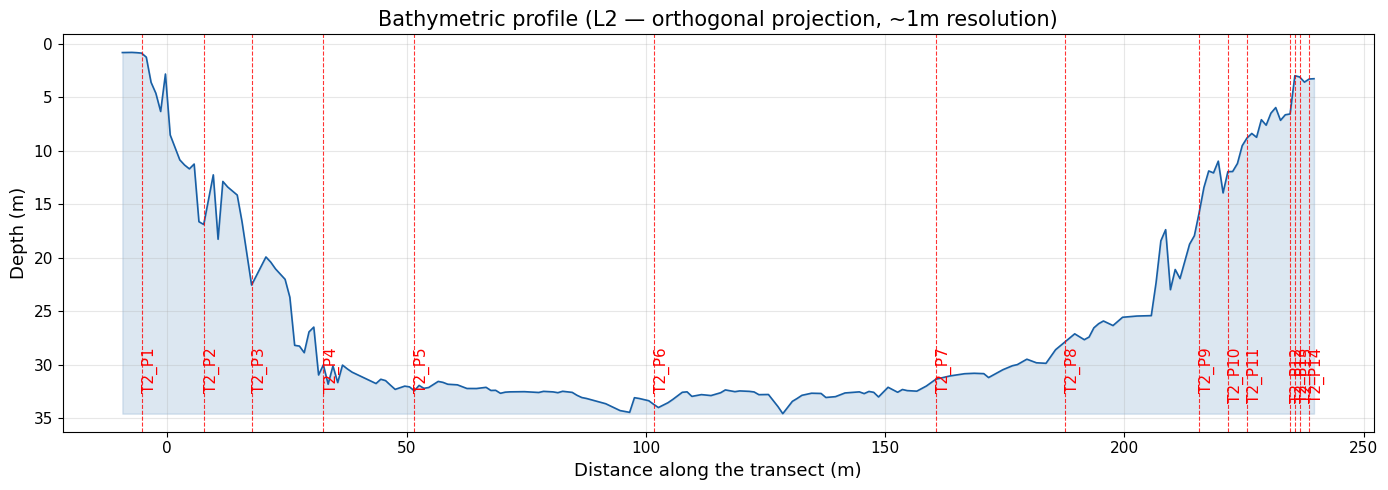

✓ transect_profil_L2.png


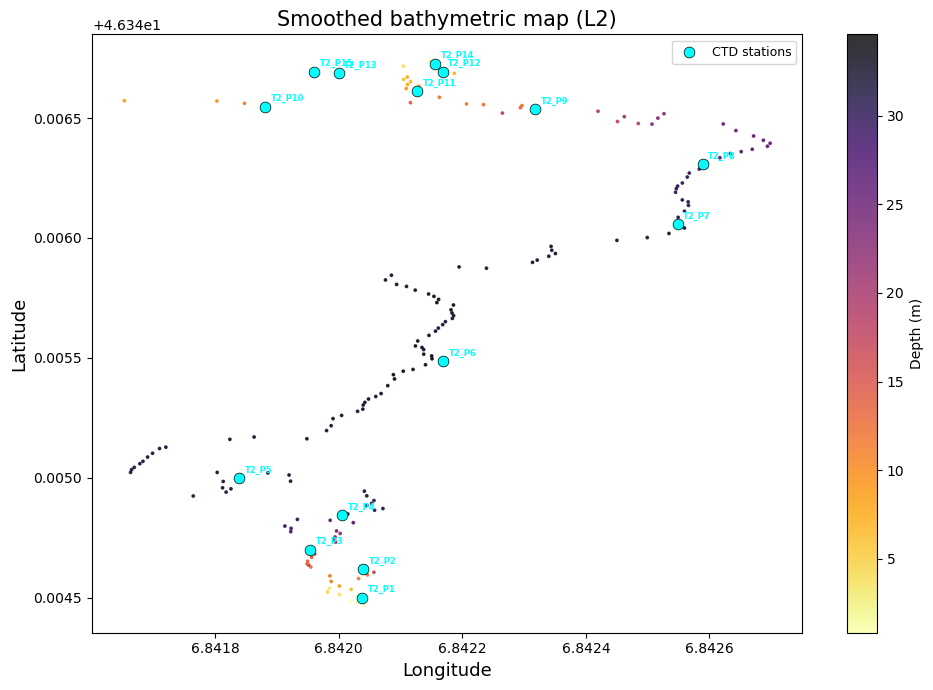

✓ carte_bathymetrique_L2.png


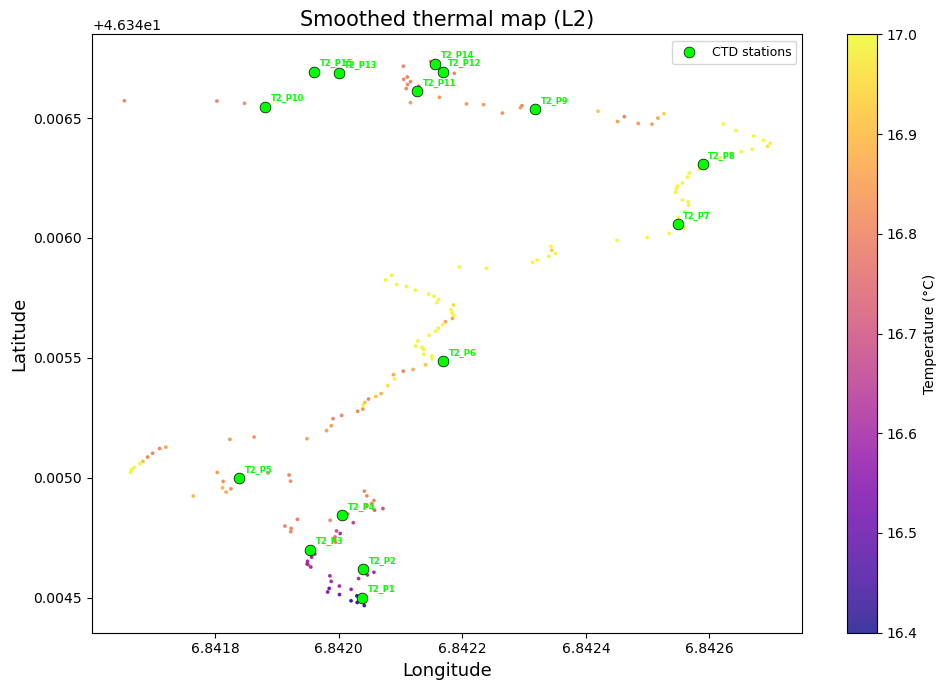

✓ carte_thermique_L2.png


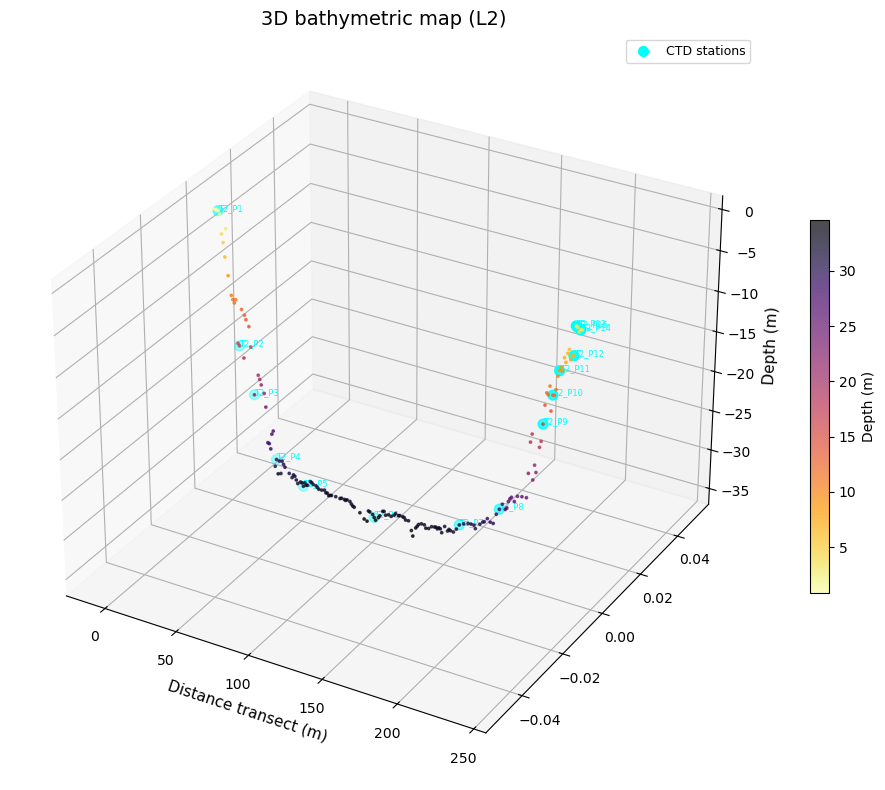

✓ visualisation_3d_L2.png


In [8]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ── Chargement du fichier NetCDF L2 ──────────────────────────────────────────
ds = xr.open_dataset(
    r"../data/bathymetry/20260603/Level2/sonar_deeper_bathymetric_level2_20260604.nc",
    engine="netcdf4"
)

# Conversion en DataFrame
df = ds.to_dataframe().reset_index()
df["datetime"] = (pd.to_datetime(df["time"], unit="s", utc=True)
                  .dt.tz_convert("Europe/Zurich"))

print(f"✓ {len(df)} points chargés")
print(f"  Profondeur max : {df['depth'].max():.2f} m")
print(f"  Température moy: {df['temperature'].mean():.2f} °C")

# ── Points CTD ────────────────────────────────────────────────────────────────
CTD_STATIONS = {
    "T2_P1":  "2026-06-04 11:30:00", "T2_P2":  "2026-06-04 11:35:00",
    "T2_P3":  "2026-06-04 11:40:00", "T2_P4":  "2026-06-04 11:46:00",
    "T2_P5":  "2026-06-04 11:50:00", "T2_P6":  "2026-06-04 11:56:00",
    "T2_P7":  "2026-06-04 12:03:00", "T2_P8":  "2026-06-04 12:07:00",
    "T2_P9":  "2026-06-04 12:14:00", "T2_P10": "2026-06-04 12:16:00",
    "T2_P11": "2026-06-04 12:18:00", "T2_P12": "2026-06-04 12:22:00",
    "T2_P13": "2026-06-04 12:24:00", "T2_P14": "2026-06-04 12:26:00",
    "T2_P15": "2026-06-04 12:28:00",
}
tz = "Europe/Zurich"
rows_ctd = {}
for name, t in CTD_STATIONS.items():
    ts = pd.Timestamp(t, tz=tz)
    idx = (df["datetime"] - ts).abs().idxmin()
    rows_ctd[name] = df.loc[idx]
df_ctd = pd.DataFrame(rows_ctd).T
df_ctd.index.name = "station"

# ── 1. Profil bathymétrique le long du transect ───────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(df["dist_transect"], df["depth"],
                df["depth"].max(), alpha=0.15, color="#185FA5")
ax.plot(df["dist_transect"], df["depth"], linewidth=1.2, color="#185FA5")
depth_max = df["depth"].max()
for name, row in df_ctd.iterrows():
    ax.axvline(row["dist_transect"], color="red", linewidth=0.8,
               linestyle="--", alpha=0.8)
    ax.text(row["dist_transect"], depth_max * 0.82,
            name, fontsize=11, color="red", rotation=90, va="top")
ax.invert_yaxis()
ax.set_xlabel("Distance along the transect (m)", fontsize=13)
ax.set_ylabel("Depth (m)", fontsize=13)
ax.set_title("Bathymetric profile (L2 — orthogonal projection, ~1m resolution)", fontsize=15)
ax.tick_params(labelsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Figures/transect_profil_L2.png", dpi=150)
plt.show()
print("✓ transect_profil_L2.png")

# ── 2. Carte bathymétrique lissée ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(df["longitude"], df["latitude"],
                c=df["depth"], cmap="inferno_r", s=3, alpha=0.8)
plt.colorbar(sc, ax=ax, label="Depth (m)")
ax.scatter(df_ctd["longitude"], df_ctd["latitude"],
           color="cyan", s=60, zorder=7, edgecolors="black",
           linewidths=0.5, label="CTD stations")
for name, row in df_ctd.iterrows():
    ax.annotate(name, (row["longitude"], row["latitude"]),
                fontsize=6, color="cyan", fontweight="bold",
                xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("Longitude", fontsize=13)
ax.set_ylabel("Latitude", fontsize=13)
ax.set_title("Smoothed bathymetric map (L2)", fontsize=15)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("Figures/carte_bathymetrique_L2.png", dpi=150)
plt.show()
print("✓ carte_bathymetrique_L2.png")

# ── 3. Carte thermique lissée ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(df["longitude"], df["latitude"],
                c=df["temperature"], cmap="plasma", s=3, alpha=0.8)
plt.colorbar(sc, ax=ax, label="Temperature (°C)")
ax.scatter(df_ctd["longitude"], df_ctd["latitude"],
           color="lime", s=60, zorder=5, edgecolors="black",
           linewidths=0.5, label="CTD stations")
for name, row in df_ctd.iterrows():
    ax.annotate(name, (row["longitude"], row["latitude"]),
                fontsize=6, color="lime", fontweight="bold",
                xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("Longitude", fontsize=13)
ax.set_ylabel("Latitude", fontsize=13)
ax.set_title("Smoothed thermal map (L2)", fontsize=15)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("Figures/carte_thermique_L2.png", dpi=150)
plt.show()
print("✓ carte_thermique_L2.png")

# ── 4. Visualisation 3D ───────────────────────────────────────────────────────
fig = plt.figure(figsize=(11, 8))
ax3d = fig.add_subplot(111, projection="3d")
sc3d = ax3d.scatter(
    df["dist_transect"], np.zeros(len(df)), -df["depth"],
    c=df["depth"], cmap="inferno_r", s=3, alpha=0.7
)
ax3d.scatter(df_ctd["dist_transect"], np.zeros(len(df_ctd)), -df_ctd["depth"],
             color="cyan", s=50, zorder=5, label="CTD stations")
for name, row in df_ctd.iterrows():
    ax3d.text(row["dist_transect"], 0, -row["depth"],
              name, fontsize=6, color="cyan")
plt.colorbar(sc3d, ax=ax3d, label="Depth (m)", shrink=0.5)
ax3d.set_xlabel("Distance transect (m)", fontsize=11)
ax3d.set_ylabel("")
ax3d.set_zlabel("Depth (m)", fontsize=11)
ax3d.set_title("3D bathymetric map (L2)", fontsize=14)
ax3d.legend(fontsize=9)
plt.tight_layout()
plt.savefig("Figures/visualisation_3d_L2.png", dpi=150)
plt.show()
print("✓ visualisation_3d_L2.png")

